In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from utils import load_or_fetch  # your Project 1 helper
from plot_setup import setup_chinese_font
setup_chinese_font()

# Zhenyuan (小盘股) and Gongshang (大盘股)
zhenyuan = load_or_fetch('sz.000705', '2024-01-01', '2024-12-31', 'data/prices')
gongshang = load_or_fetch('sh.601398', '2024-01-01', '2024-12-31', 'data/prices')

# Log returns
zhenyuan['log_ret'] = np.log(zhenyuan['close'] / zhenyuan['close'].shift(1))
gongshang['log_ret'] = np.log(gongshang['close'] / gongshang['close'].shift(1))

# Drop the first NaN
zy_ret = zhenyuan['log_ret'].dropna()
gs_ret = gongshang['log_ret'].dropna()

print(f"震元:  N = {len(zy_ret)}, mean = {zy_ret.mean():.5f}, std = {zy_ret.std():.5f}")
print(f"工商:  N = {len(gs_ret)}, mean = {gs_ret.mean():.5f}, std = {gs_ret.std():.5f}")

震元:  N = 241, mean = -0.00130, std = 0.02741
工商:  N = 241, mean = 0.00174, std = 0.01281


In [2]:
# Manual lag-1 autocorrelation on 震元
today = zy_ret.iloc[1:].values       # days 2 through end
yesterday = zy_ret.iloc[:-1].values  # days 1 through second-to-last

# Pearson correlation between these two aligned vectors
lag1_zy_manual = np.corrcoef(today, yesterday)[0, 1]
print(f"震元 lag-1 AC (manual):   {lag1_zy_manual:.4f}")

# Cross-check with pandas' built-in
lag1_zy_pandas = zy_ret.autocorr(lag=1)
print(f"震元 lag-1 AC (pandas):   {lag1_zy_pandas:.4f}")

# Same for 工商
lag1_gs_manual = np.corrcoef(gs_ret.iloc[1:].values, gs_ret.iloc[:-1].values)[0, 1]
lag1_gs_pandas = gs_ret.autocorr(lag=1)
print(f"工商 lag-1 AC (manual):   {lag1_gs_manual:.4f}")
print(f"工商 lag-1 AC (pandas):   {lag1_gs_pandas:.4f}")

震元 lag-1 AC (manual):   -0.0050
震元 lag-1 AC (pandas):   -0.0050
工商 lag-1 AC (manual):   -0.0596
工商 lag-1 AC (pandas):   -0.0596


In [4]:
N = len(zy_ret)
sig_threshold = 1.96 / np.sqrt(N)
print(f"95% significance band: ±{sig_threshold:.4f}")

95% significance band: ±0.1263


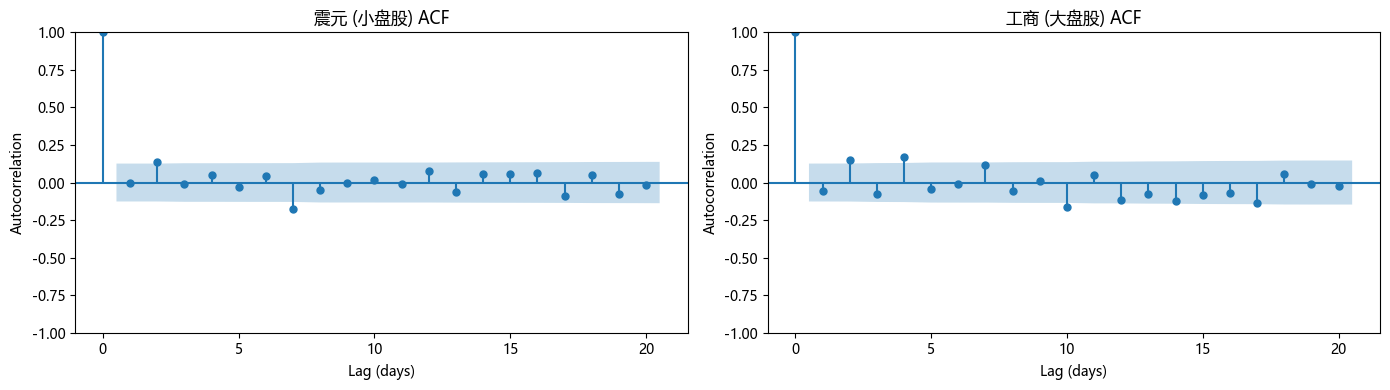

In [5]:
from statsmodels.graphics.tsaplots import plot_acf

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

plot_acf(zy_ret, lags=20, ax=axes[0], title='震元 (小盘股) ACF')
axes[0].set_xlabel('Lag (days)')
axes[0].set_ylabel('Autocorrelation')

plot_acf(gs_ret, lags=20, ax=axes[1], title='工商 (大盘股) ACF')
axes[1].set_xlabel('Lag (days)')
axes[1].set_ylabel('Autocorrelation')

plt.tight_layout()
plt.savefig('session4_acf_comparison.png', dpi=120, bbox_inches='tight')
plt.show()

In [6]:
from statsmodels.stats.diagnostic import acorr_ljungbox

# Test up to lag 20
lb_zy = acorr_ljungbox(zy_ret, lags=[5, 10, 20], return_df=True)
lb_gs = acorr_ljungbox(gs_ret, lags=[5, 10, 20], return_df=True)

print("震元 Ljung-Box:")
print(lb_zy)
print("\n工商 Ljung-Box:")
print(lb_gs)

震元 Ljung-Box:
      lb_stat  lb_pvalue
5    5.294124   0.381049
10  13.938448   0.175818
20  23.971282   0.243649

工商 Ljung-Box:
      lb_stat  lb_pvalue
5   15.041993   0.010184
10  25.880408   0.003904
20  44.230471   0.001402
